In [1]:
import numpy as np
import pandas as pd
import json
from itertools import combinations
import itertools
import random
from collections import defaultdict
import os
import shutil
import ast
from matplotlib import pyplot as plt
import pickle
import json
import random
from collections import defaultdict
from itertools import combinations
from itertools import permutations
from itertools import product
import pickle
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# A function to read in all complex's performance
def performanceLoading(path):

    perform_dict = {}

    for file in os.listdir(path):
        if file.endswith(".pkl"):
        
            file_path = os.path.join(path, file)

            with open(file_path, "rb") as f:
                obj = pickle.load(f)

            name = os.path.splitext(file)[0]
            perform_dict[name] = obj

    print(len(perform_dict.keys()))

    return perform_dict

With feature selection performance

In [3]:
pearsonWithSel = performanceLoading('/Users/guowanyi/Desktop/spring 2026/Louis_Vuitton/March 11 update/PearsonWithSel')
spearmanWithSel = performanceLoading('/Users/guowanyi/Desktop/spring 2026/Louis_Vuitton/March 11 update/SpearmanWithSel')
miWithSel = performanceLoading('/Users/guowanyi/Desktop/spring 2026/Louis_Vuitton/March 11 update/MiWithSel')
bicorWithSel = performanceLoading('/Users/guowanyi/Desktop/spring 2026/Louis_Vuitton/March 11 update/BicorWithSel')

27
27
27
27


Without feature selection performance

In [4]:
pearsonXsel = performanceLoading('/Users/guowanyi/Desktop/spring 2026/Louis_Vuitton/March 11 update/PearsonXsel')
spearmanXsel = performanceLoading('/Users/guowanyi/Desktop/spring 2026/Louis_Vuitton/March 11 update/SpearmanXsel')
miXsel = performanceLoading('/Users/guowanyi/Desktop/spring 2026/Louis_Vuitton/March 11 update/MiXsel')
bicorXsel = performanceLoading('/Users/guowanyi/Desktop/spring 2026/Louis_Vuitton/March 11 update/BicorXsel')

27
27
27
27


Let's re-draw the paired boxplot

In [7]:
featureSel_all = {
    "Pearson": pearsonWithSel,
    "Spearman": spearmanWithSel,
    "Mutual_info": miWithSel,
    "Bicor": bicorWithSel
}

noSel_all = {
    "Pearson": pearsonXsel,
    "Spearman": spearmanXsel,
    "Mutual_info": miXsel,
    "Bicor": bicorXsel
}

In [8]:
# A summary function

def summarize_dict(performance_dict, fs_label):
    
    rows = []
    metrics = ["train_accuracy", "test_accuracy",
               "precision", "recall",
               "f1_score", "roc_auc"]
    
    for method, complexes in performance_dict.items():
        for complex_name, trials in complexes.items():
            
            for model in list(trials.values())[0].keys():
                
                for metric in metrics:
                    
                    values = []
                    
                    for trial_name, trial_data in trials.items():
                        if trial_data is None:
                            continue
                        values.append(trial_data[model][metric])
                    
                    if len(values) == 0:
                        continue
                    
                    rows.append({
                        "Method": method,
                        "Complex": complex_name,
                        "Model": model,
                        "Metric": metric,
                        "Mean": np.mean(values),
                        "FeatureSelection": fs_label
                    })
    
    return pd.DataFrame(rows)

In [9]:
df_fs = summarize_dict(featureSel_all, "With FS")
df_nofs = summarize_dict(noSel_all, "Without FS")

combined_df = pd.concat([df_fs, df_nofs], ignore_index=True)
combined_df.head()

,Method,Complex,Model,Metric,Mean,FeatureSelection
0,Pearson,ATRCHK1_checkpoint_complex_10pearsonWithSel_pe...,Gradient Boosting Classifier,train_accuracy,1.000000,With FS
1,Pearson,ATRCHK1_checkpoint_complex_10pearsonWithSel_pe...,Gradient Boosting Classifier,test_accuracy,0.808333,With FS
2,Pearson,ATRCHK1_checkpoint_complex_10pearsonWithSel_pe...,Gradient Boosting Classifier,precision,0.800000,With FS
3,Pearson,ATRCHK1_checkpoint_complex_10pearsonWithSel_pe...,Gradient Boosting Classifier,recall,0.850000,With FS
4,Pearson,ATRCHK1_checkpoint_complex_10pearsonWithSel_pe...,Gradient Boosting Classifier,f1_score,0.800000,With FS


In [10]:
# A visualization function

def plot_metric_with_fs(combined_df, metric_name):

    df_plot = combined_df[combined_df["Metric"] == metric_name]

    method_palette = {
        "With FS": "#4C72B0",
        "Without FS": "#DD8452"
    }

    g = sns.catplot(
        data=df_plot,
        x="Method",
        y="Mean",
        hue="FeatureSelection",
        col="Model",
        kind="box",
        col_wrap=3,
        height=4,
        aspect=1.2,
        palette=method_palette,
        sharey=True
    )

    g.fig.subplots_adjust(top=0.9)
    g.fig.suptitle(f"{metric_name} across complexes (with vs without feature selection)", fontsize=16)

    for ax in g.axes.flatten():
        ax.tick_params(axis='x', rotation=45)

    plt.show()

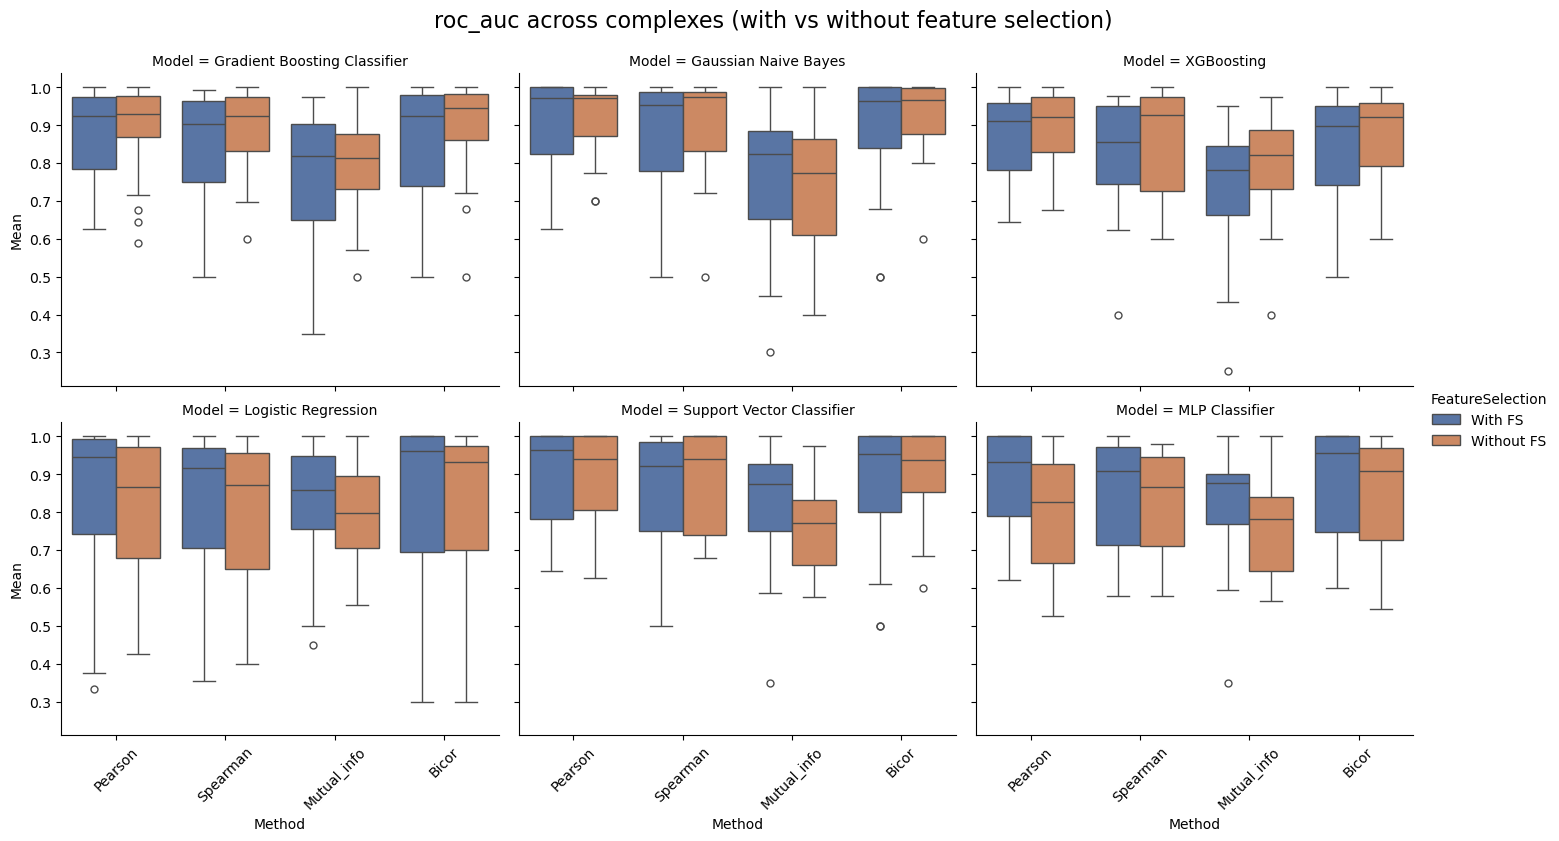

In [15]:
plot_metric_with_fs(combined_df, "roc_auc")

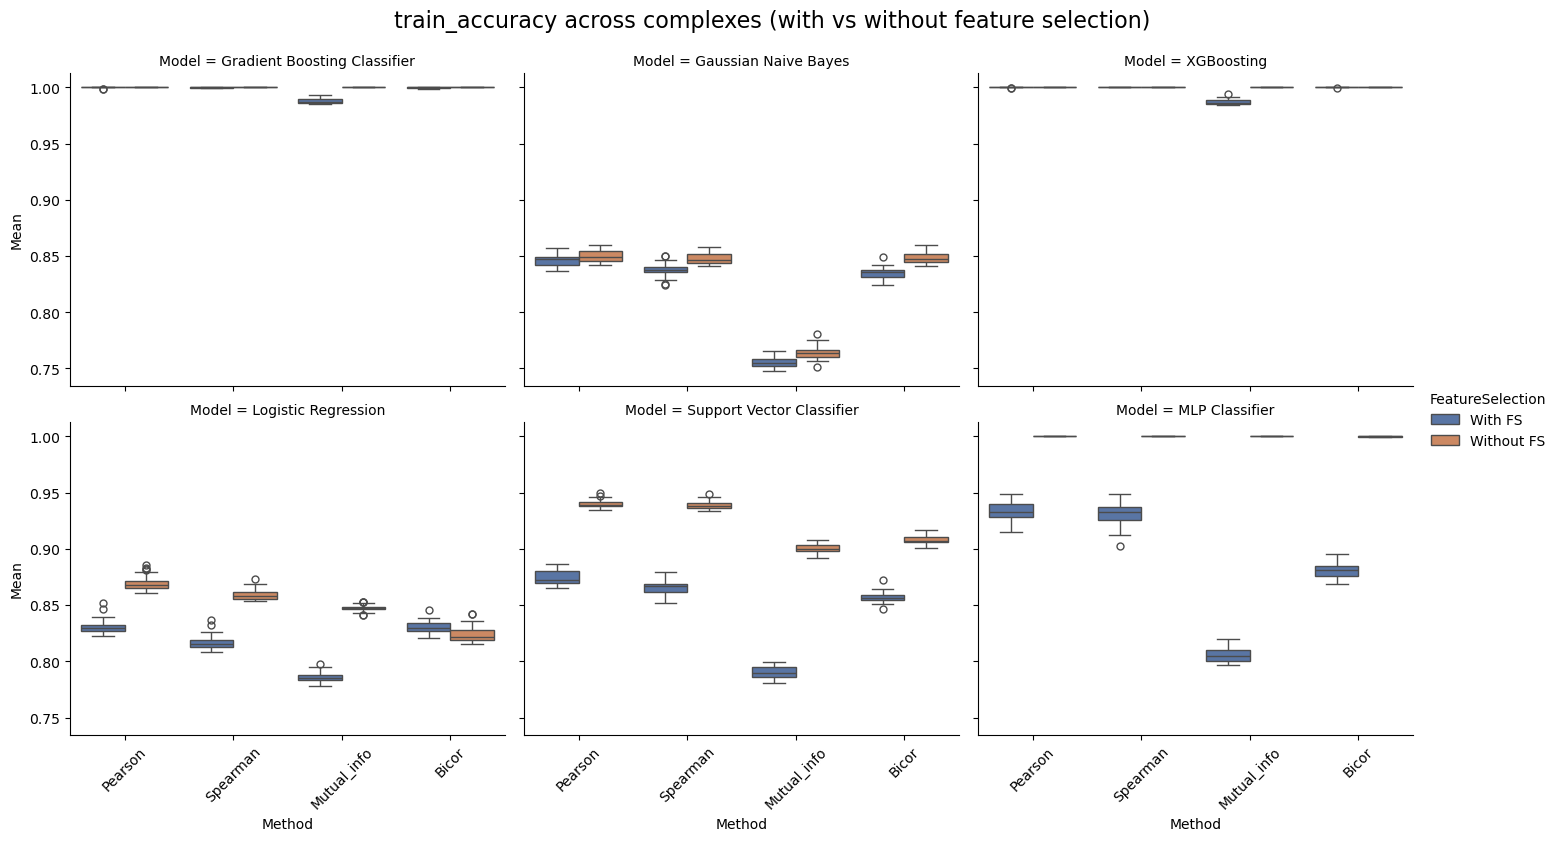

In [16]:
plot_metric_with_fs(combined_df, "train_accuracy")

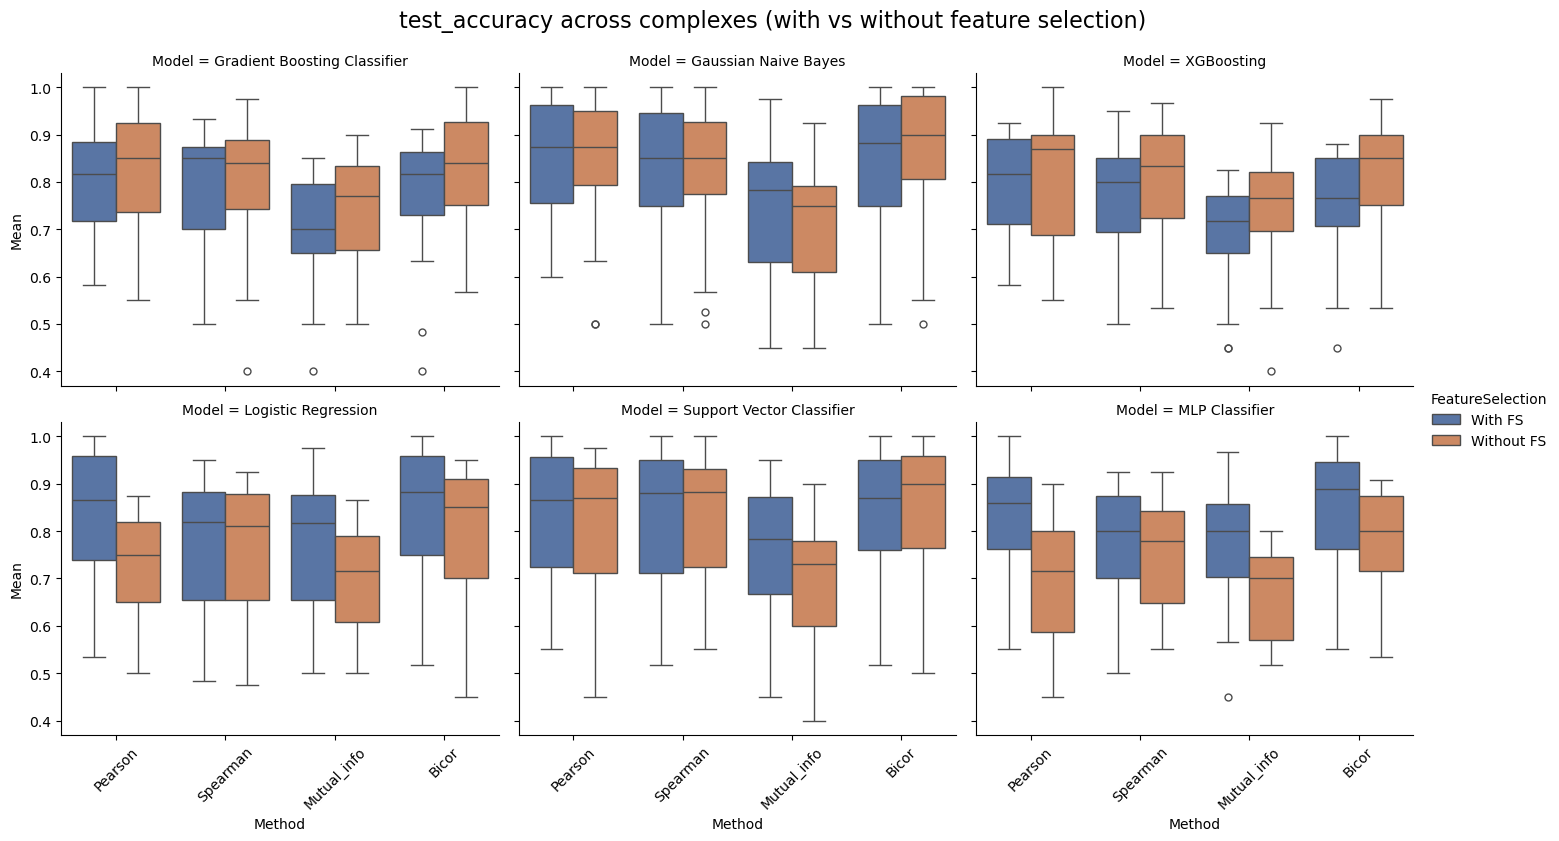

In [17]:
plot_metric_with_fs(combined_df, "test_accuracy")

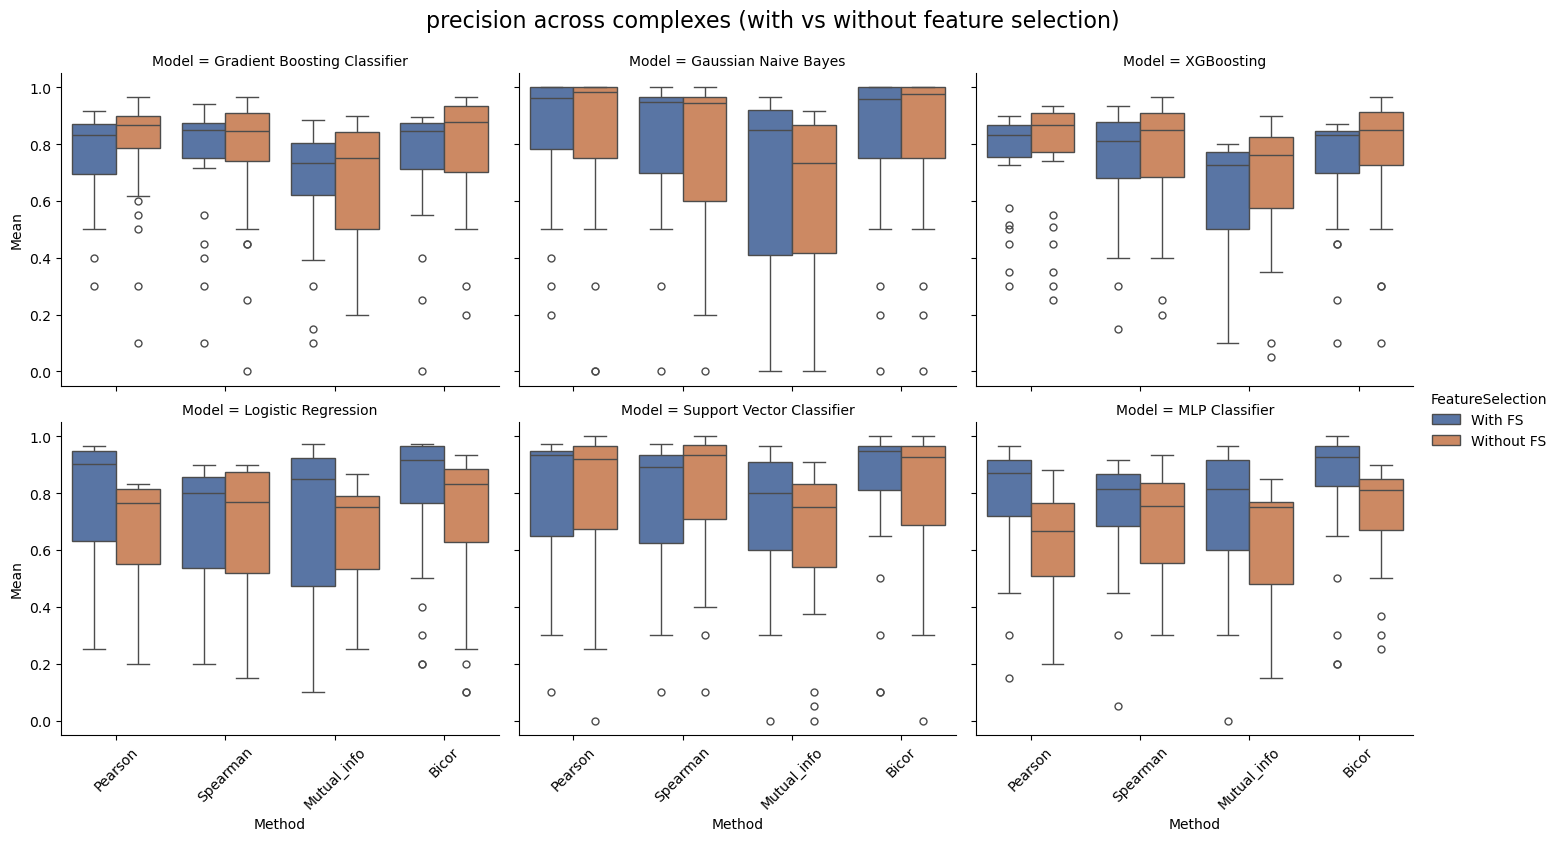

In [18]:
plot_metric_with_fs(combined_df, "precision")

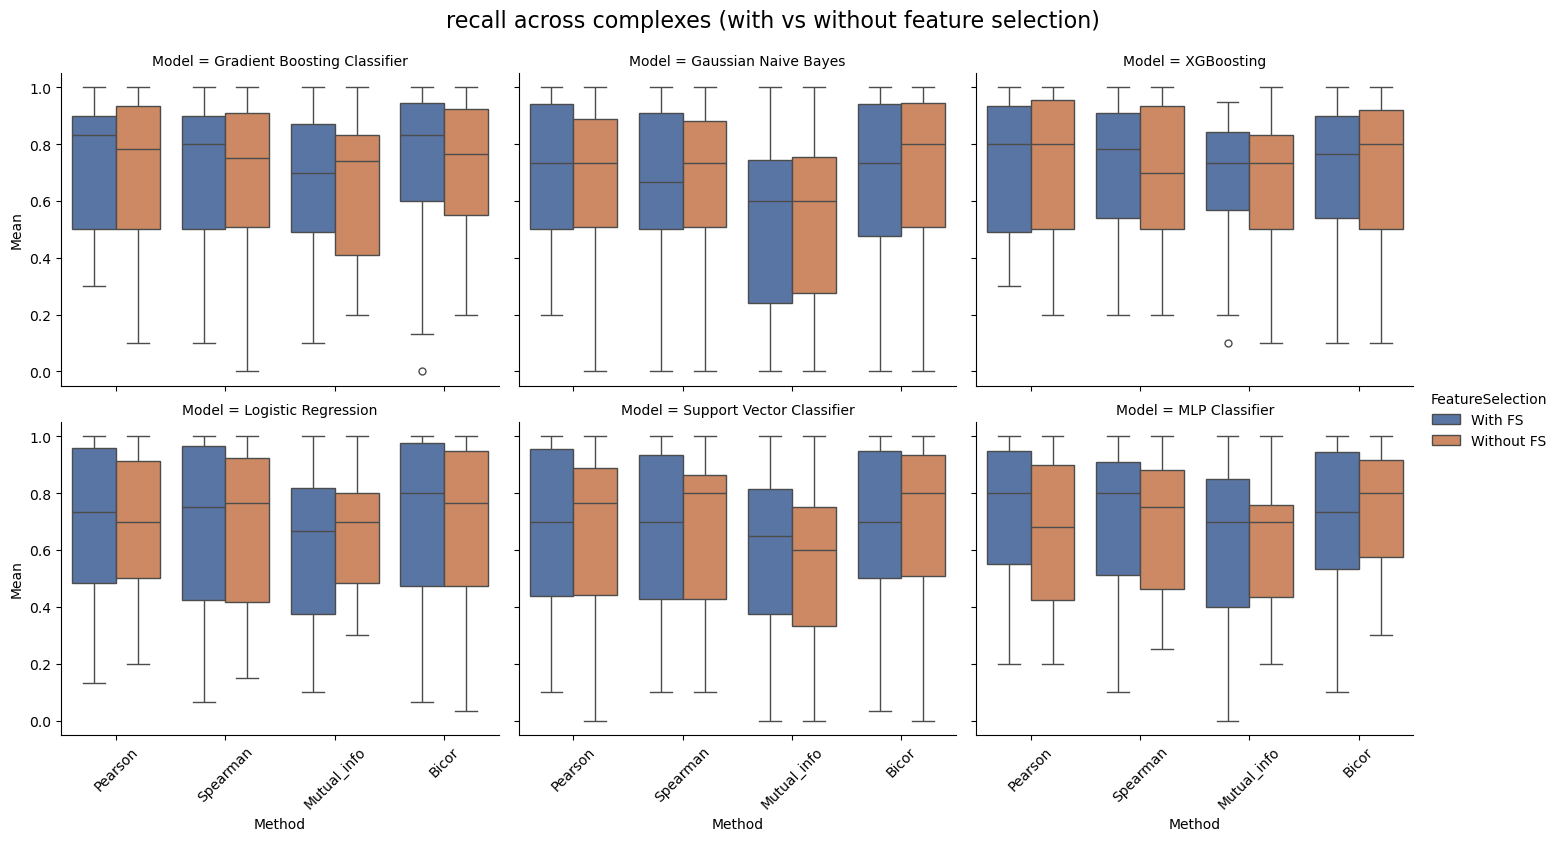

In [19]:
plot_metric_with_fs(combined_df, "recall")

ROC AUC curve

A pooled global ROC 

In [11]:
from sklearn.metrics import roc_curve, auc

In [12]:
def pool_predictions(method_results, model_name):

    all_y_test = []
    all_y_score = []

    for complex_name in method_results:

        trials = method_results[complex_name]

        for trial in trials:

            model_res = trials[trial][model_name]

            all_y_test.extend(model_res["y_test"])
            all_y_score.extend(model_res["y_score"])

    return np.array(all_y_test), np.array(all_y_score)

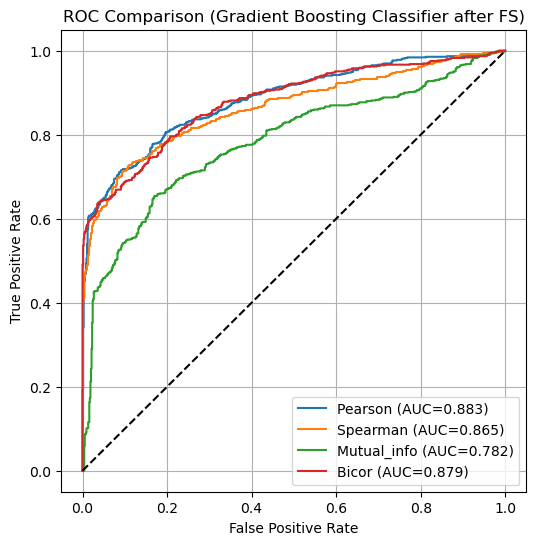

In [25]:
plt.figure(figsize=(6,6))

model_name = "Gradient Boosting Classifier"

for method_name, method_results in featureSel_all.items():

    y_test, y_score = pool_predictions(method_results, model_name)

    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{method_name} (AUC={roc_auc:.3f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Comparison ({model_name} after FS)")
plt.legend()
plt.grid(True)

plt.show()

In [13]:
all_model_names = list(set(combined_df["Model"]))
all_model_names

['XGBoosting',
 'Gaussian Naive Bayes',
 'Logistic Regression',
 'MLP Classifier',
 'Support Vector Classifier',
 'Gradient Boosting Classifier']

In [31]:
os.chdir('/Users/guowanyi/Desktop/spring 2026/Louis_Vuitton/March 11 update/ROCs after FS')
os.getcwd()

'/Users/guowanyi/Desktop/spring 2026/Louis_Vuitton/March 11 update/ROCs after FS'

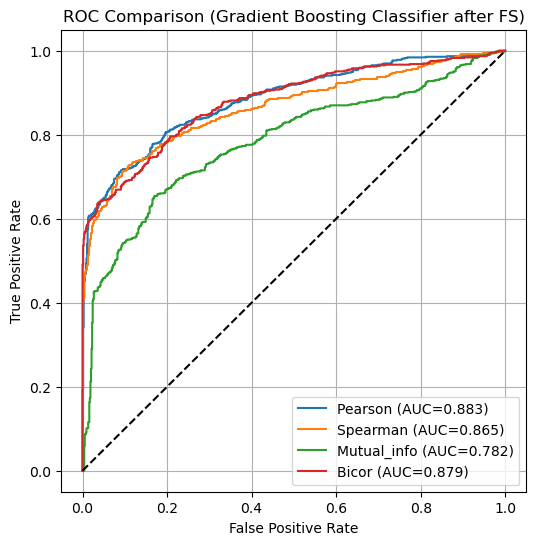

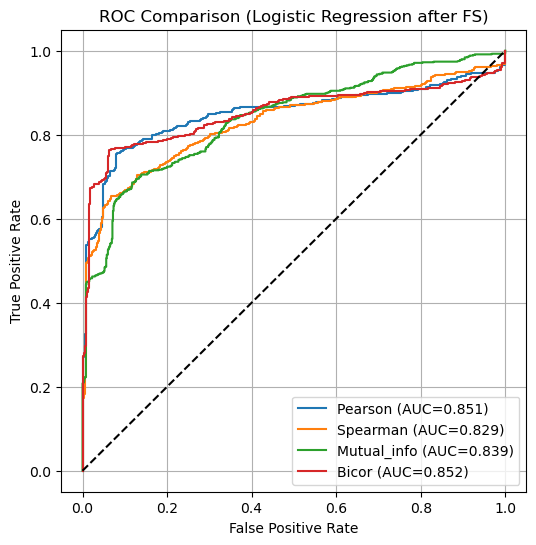

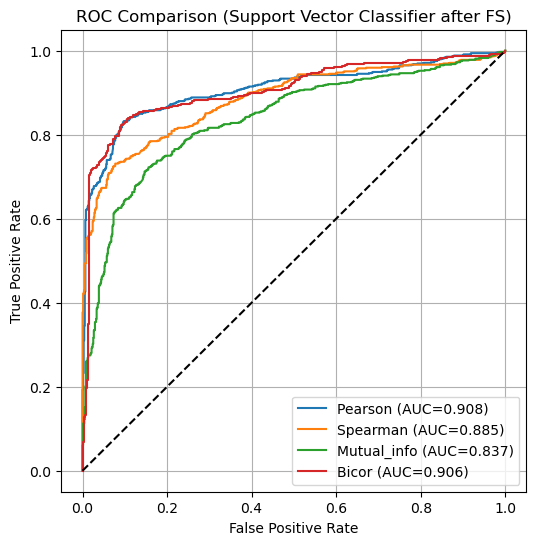

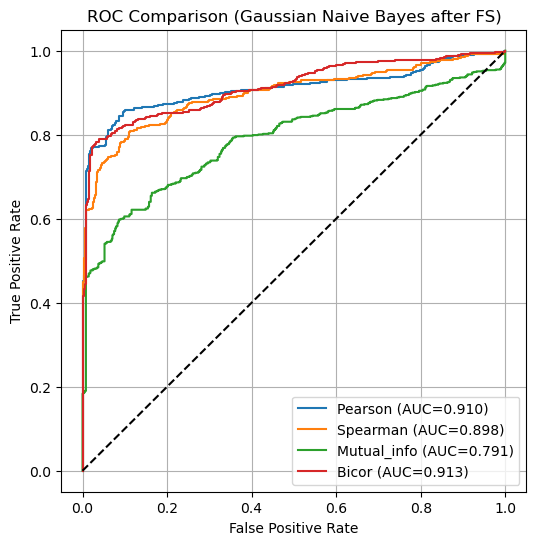

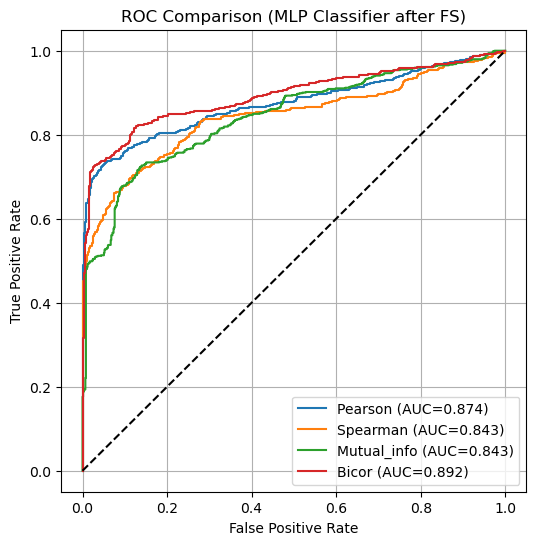

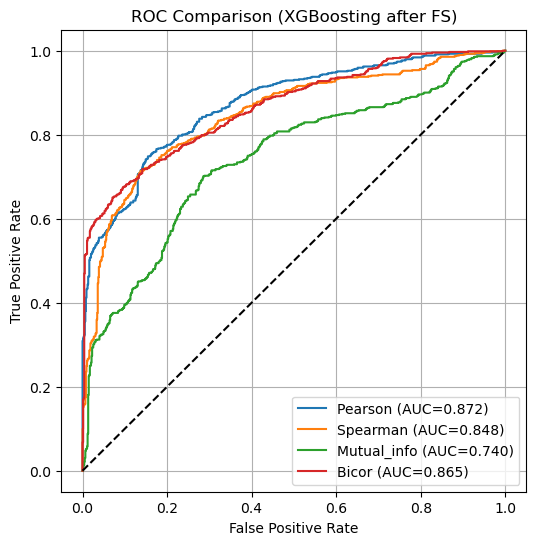

In [34]:
# Plot the global pooled ROC for every model with different methods (after feature selection)
for model_name in all_model_names:

    plt.figure(figsize=(6,6))

    for method_name, method_results in featureSel_all.items():

        y_test, y_score = pool_predictions(method_results, model_name)

        fpr, tpr, _ = roc_curve(y_test, y_score)
        roc_auc = auc(fpr, tpr)

        plt.plot(fpr, tpr, label=f"{method_name} (AUC={roc_auc:.3f})")

    plt.plot([0,1],[0,1],'k--')

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Comparison ({model_name} after FS)")
    plt.legend()
    plt.grid(True)
    plt.savefig(f"ROC Comparison ({model_name} after FS)", dpi = 300)

    plt.show()


In [14]:
os.chdir('/Users/guowanyi/Desktop/spring 2026/Louis_Vuitton/March 11 update/ROCs before FS')
os.getcwd()

'/Users/guowanyi/Desktop/spring 2026/Louis_Vuitton/March 11 update/ROCs before FS'

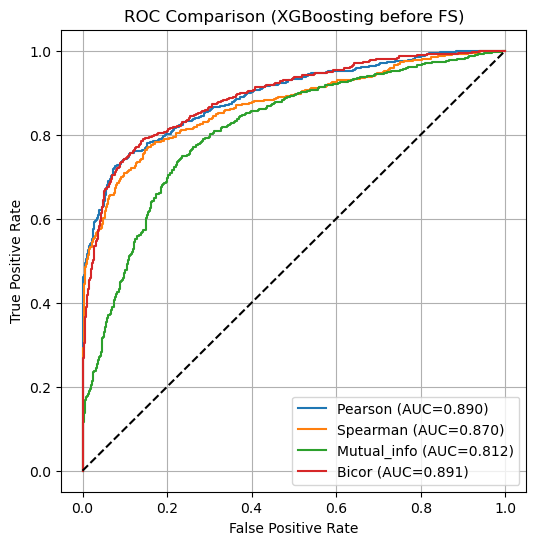

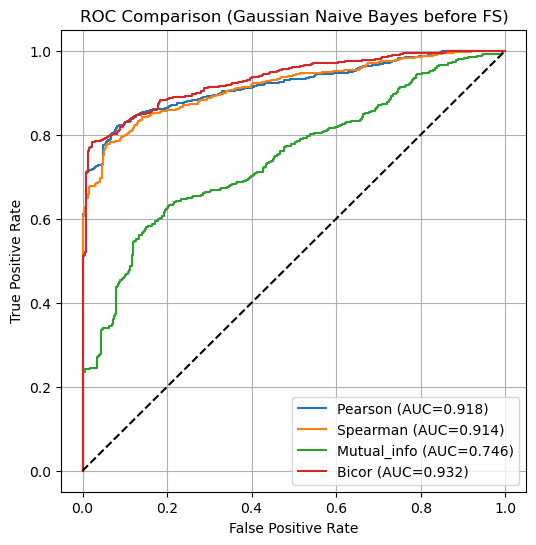

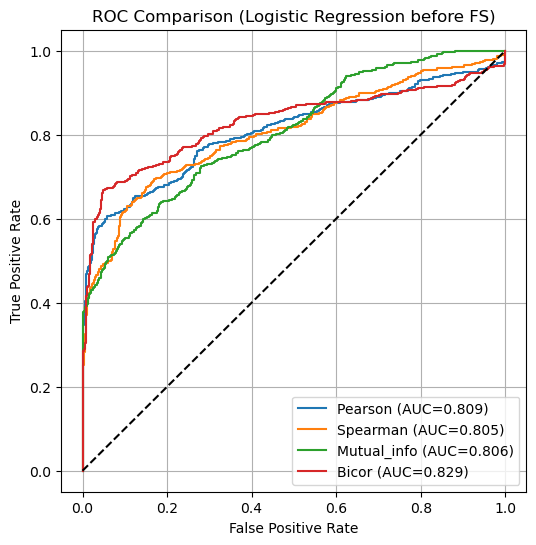

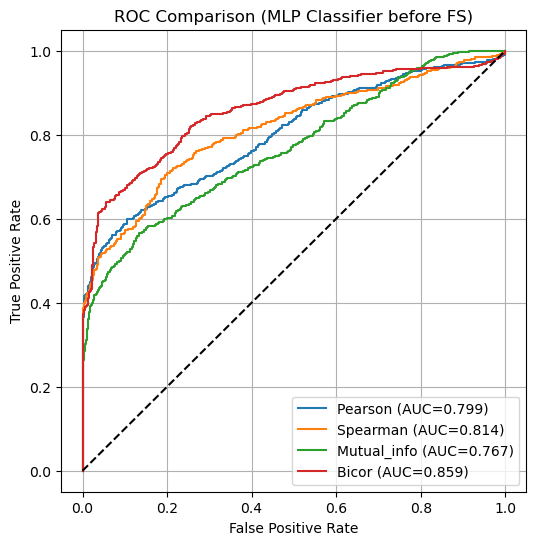

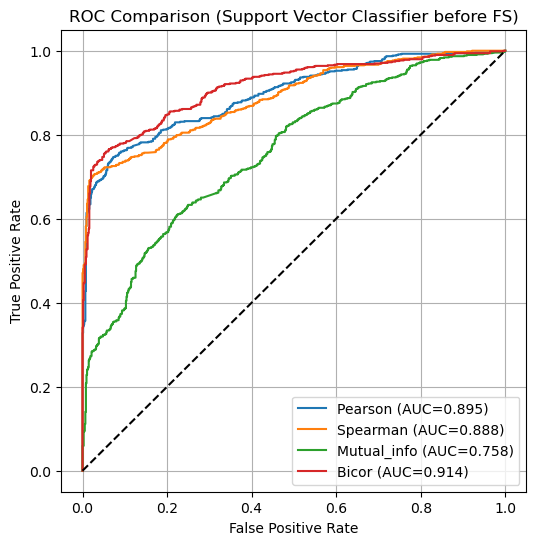

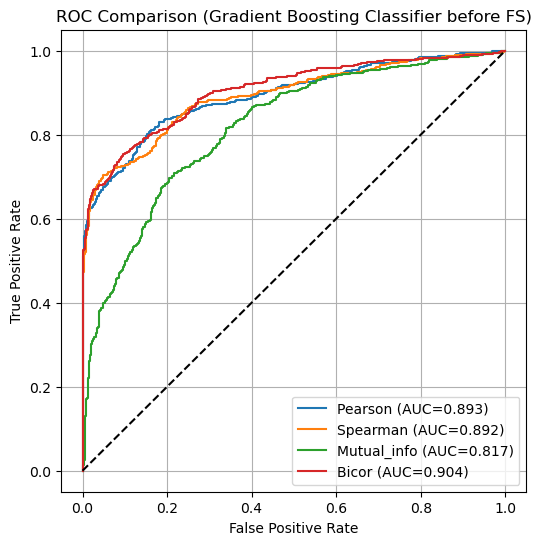

In [15]:
for model_name in all_model_names:

    plt.figure(figsize=(6,6))

    for method_name, method_results in noSel_all.items():

        y_test, y_score = pool_predictions(method_results, model_name)

        fpr, tpr, _ = roc_curve(y_test, y_score)
        roc_auc = auc(fpr, tpr)

        plt.plot(fpr, tpr, label=f"{method_name} (AUC={roc_auc:.3f})")

    plt.plot([0,1],[0,1],'k--')

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Comparison ({model_name} before FS)")
    plt.legend()
    plt.grid(True)
    plt.savefig(f"ROC Comparison ({model_name} before FS)", dpi = 300)

    plt.show()

PR Curve

In [16]:
from sklearn.metrics import precision_recall_curve, average_precision_score

In [36]:
os.chdir('/Users/guowanyi/Desktop/spring 2026/Louis_Vuitton/March 11 update/PR after FS')
os.getcwd()

'/Users/guowanyi/Desktop/spring 2026/Louis_Vuitton/March 11 update/PR after FS'

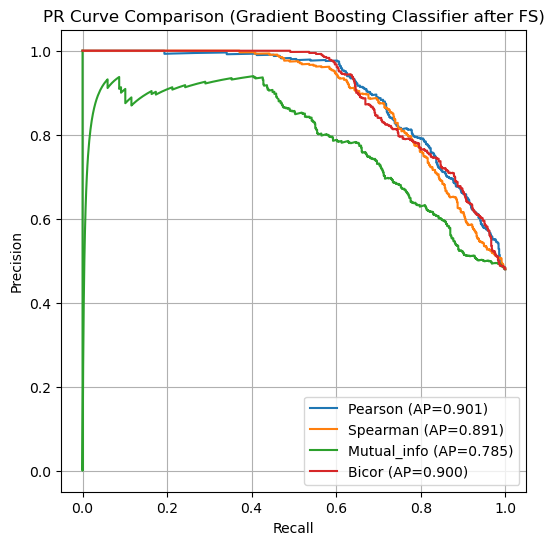

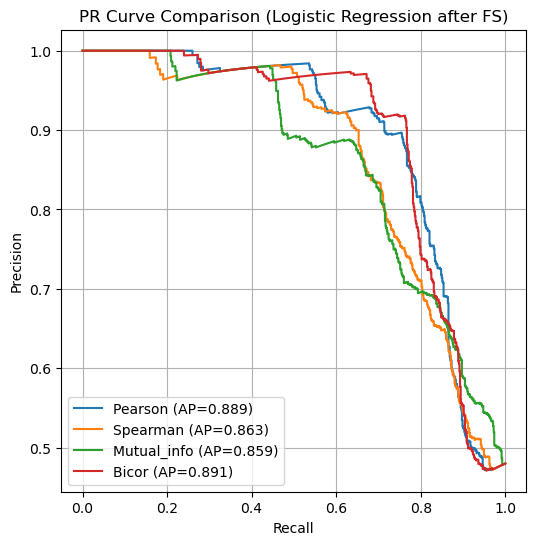

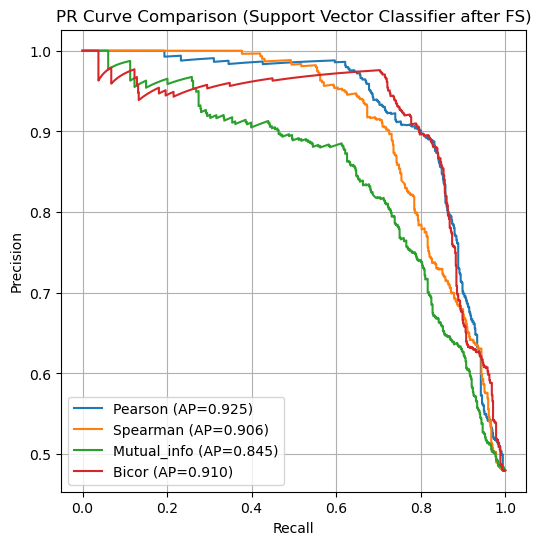

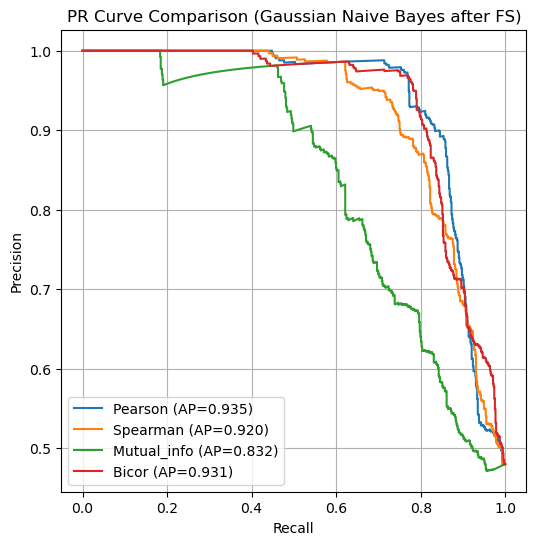

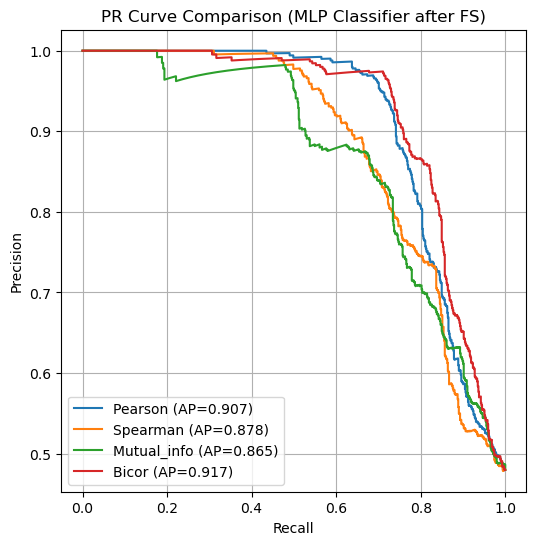

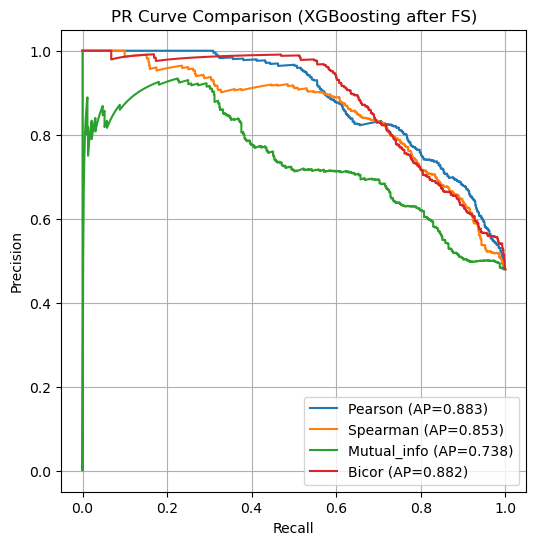

In [37]:
for model_name in all_model_names:

    plt.figure(figsize=(6,6))


    for method_name, method_results in featureSel_all.items():

        y_test, y_score = pool_predictions(method_results, model_name)

        precision, recall, _ = precision_recall_curve(y_test, y_score)
        ap = average_precision_score(y_test, y_score)

        plt.plot(recall, precision, label=f"{method_name} (AP={ap:.3f})")

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"PR Curve Comparison ({model_name} after FS)")
    plt.legend()
    plt.grid(True)
    plt.savefig(f"PR Curve Comparison ({model_name} after FS)", dpi = 300)

    plt.show()

In [17]:
os.chdir('/Users/guowanyi/Desktop/spring 2026/Louis_Vuitton/March 11 update/PR before FS')
os.getcwd()

'/Users/guowanyi/Desktop/spring 2026/Louis_Vuitton/March 11 update/PR before FS'

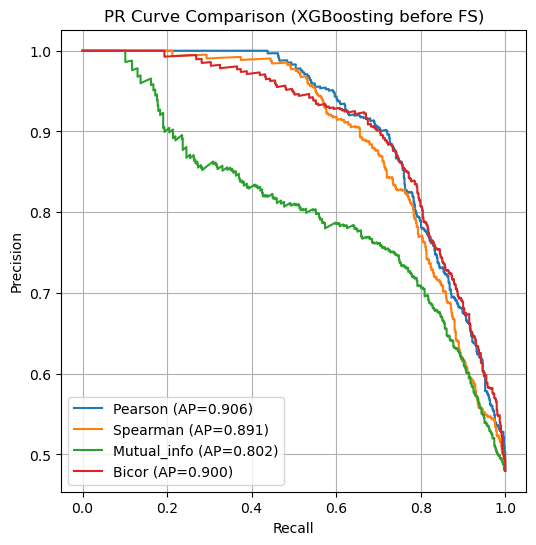

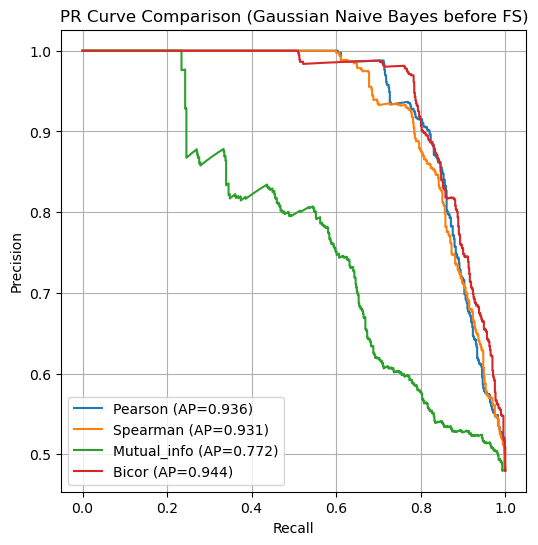

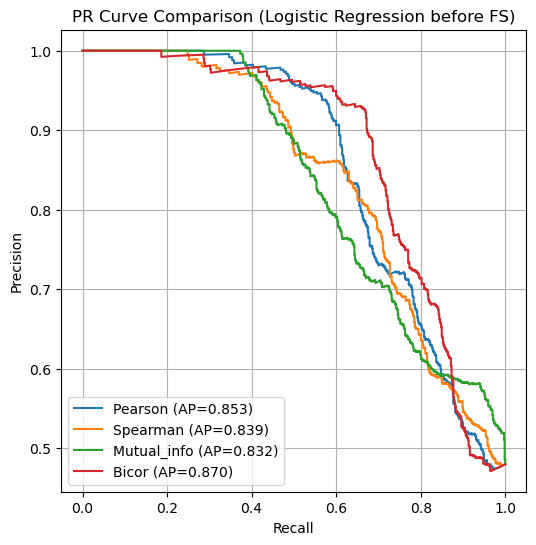

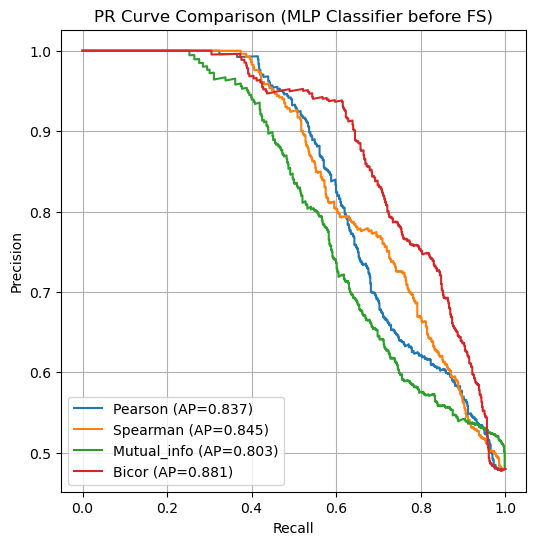

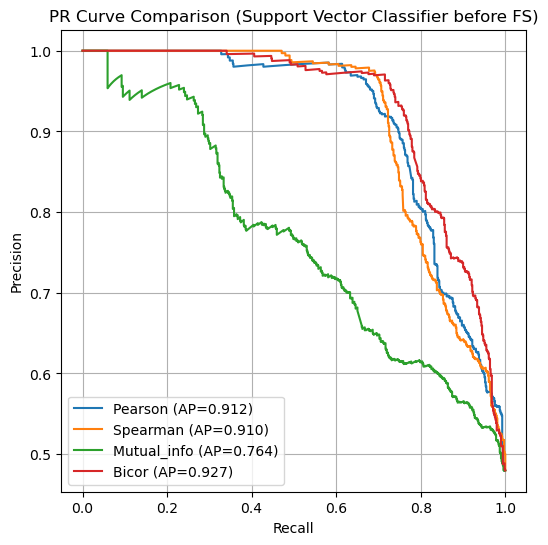

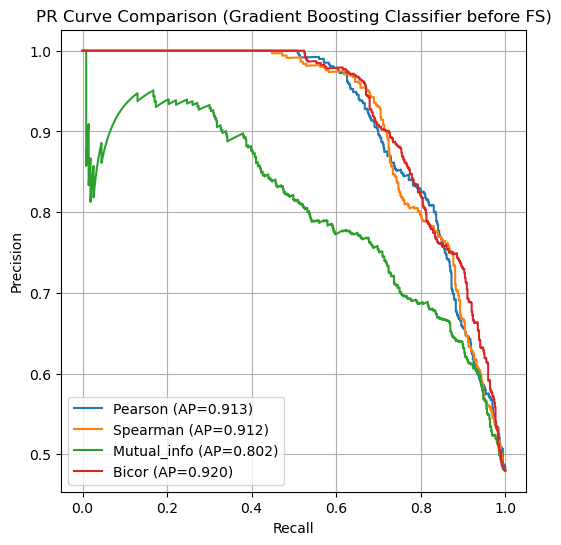

In [18]:
for model_name in all_model_names:

    plt.figure(figsize=(6,6))


    for method_name, method_results in noSel_all.items():

        y_test, y_score = pool_predictions(method_results, model_name)

        precision, recall, _ = precision_recall_curve(y_test, y_score)
        ap = average_precision_score(y_test, y_score)

        plt.plot(recall, precision, label=f"{method_name} (AP={ap:.3f})")

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"PR Curve Comparison ({model_name} before FS)")
    plt.legend()
    plt.grid(True)
    plt.savefig(f"PR Curve Comparison ({model_name} before FS)", dpi = 300)

    plt.show()